In [1]:
!pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import warnings


warnings.filterwarnings("ignore")

--- Caricamento dati da: Zeri_Tommaso.xlsx (Foglio: Ex.3) ---
Dati caricati: 400 osservazioni.
                 Oil  Inflation    Growth
obs                                      
1973-01-01  0.000000   0.000000  0.000000
1973-02-01  0.272697   0.575541 -0.183382
1973-03-01 -0.172699  -0.265970 -0.426641
1973-04-01 -0.308601  -0.522623  0.182333
1973-05-01 -0.106706  -0.080620 -0.272358
--------------------------------------------------


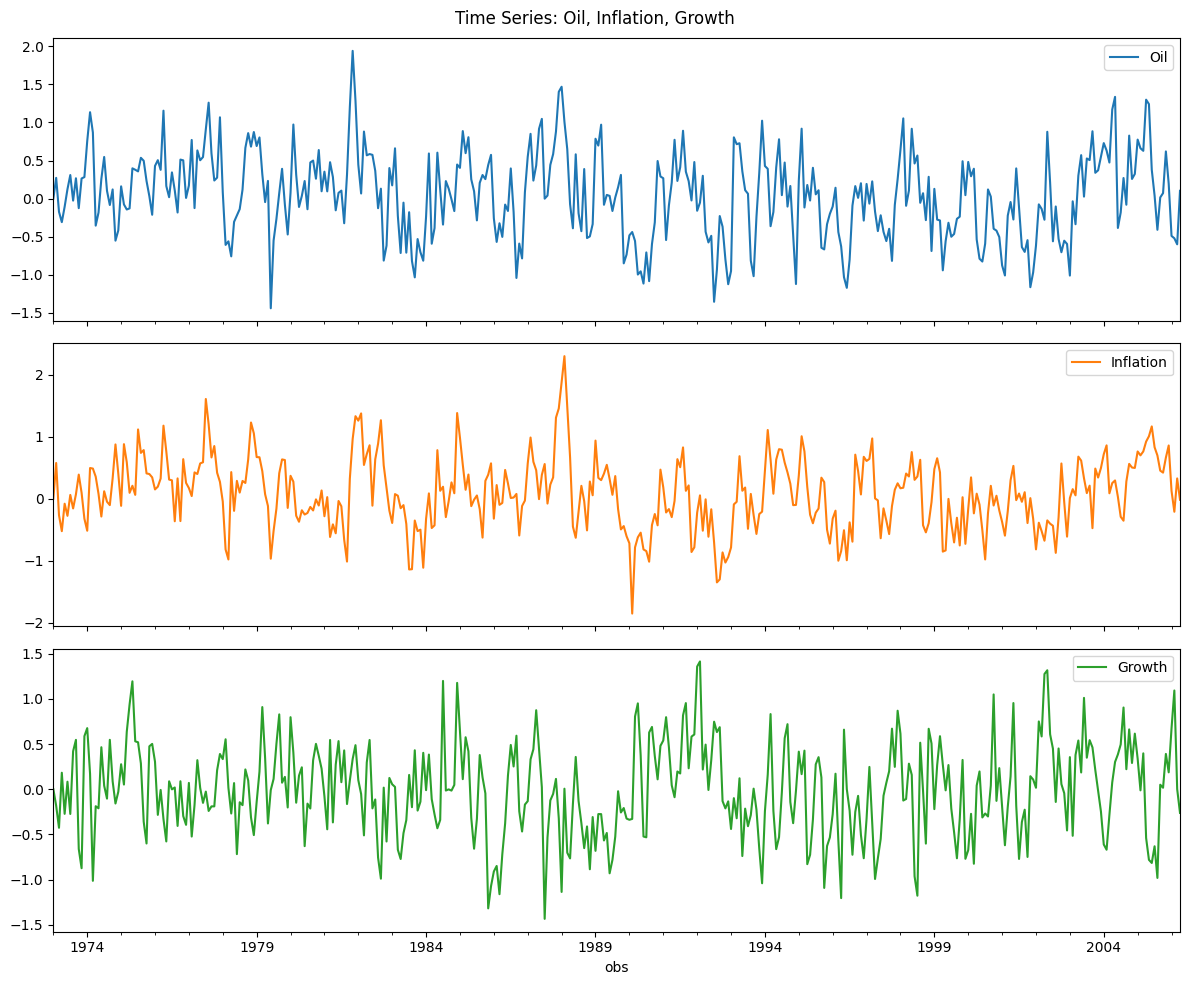

--- Verifica Stazionarietà ---
ADF Test: Oil
   Test Statistic: -9.9540
   p-value:        0.0000
   => STAZIONARIA (H0 rifiutata)

ADF Test: Inflation
   Test Statistic: -8.9084
   p-value:        0.0000
   => STAZIONARIA (H0 rifiutata)

ADF Test: Growth
   Test Statistic: -6.3087
   p-value:        0.0000
   => STAZIONARIA (H0 rifiutata)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -3.971      -3.940     0.01886      -3.959
1      -5.113*     -4.991*   0.006016*     -5.065*
2       -5.080      -4.867    0.006218      -4.996
3       -5.053      -4.748    0.006390      -4.932
4       -5.023      -4.627    0.006584      -4.866
5       -5.012      -4.524    0.006656      -4.819
6       -4.987      -4.408    0.006826      -4.757
7       -4.967      -4.296    0.006965      -4.701
8       -4.946      -4.183    0.007116      -4.644
9       -4.929      -4.075    0.007240      -

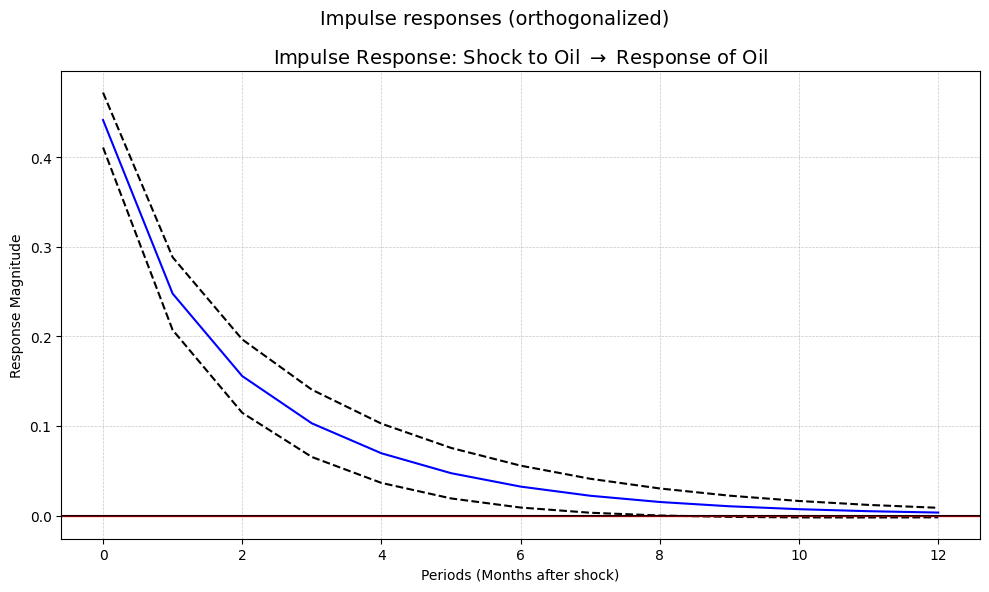

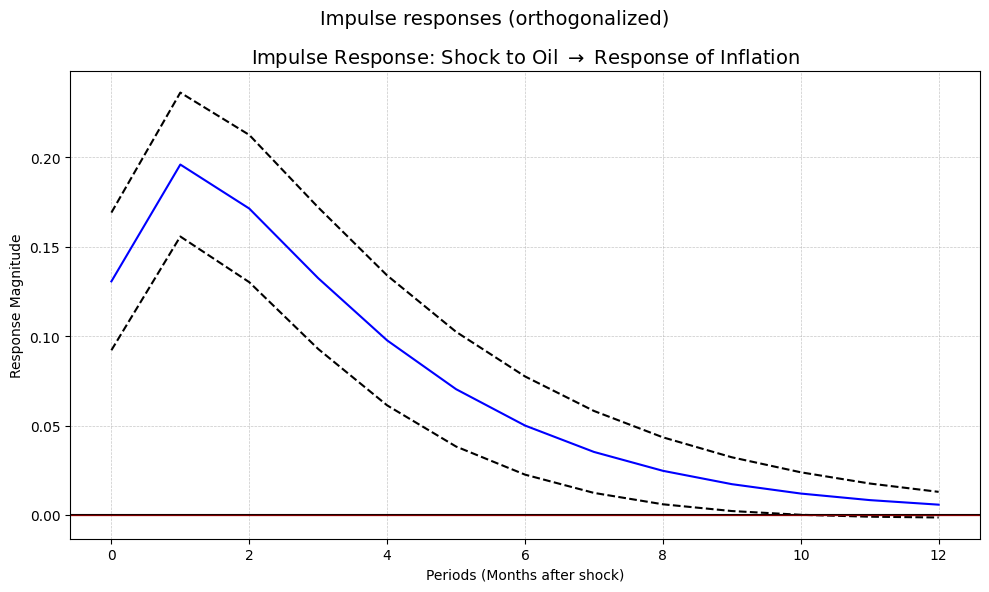

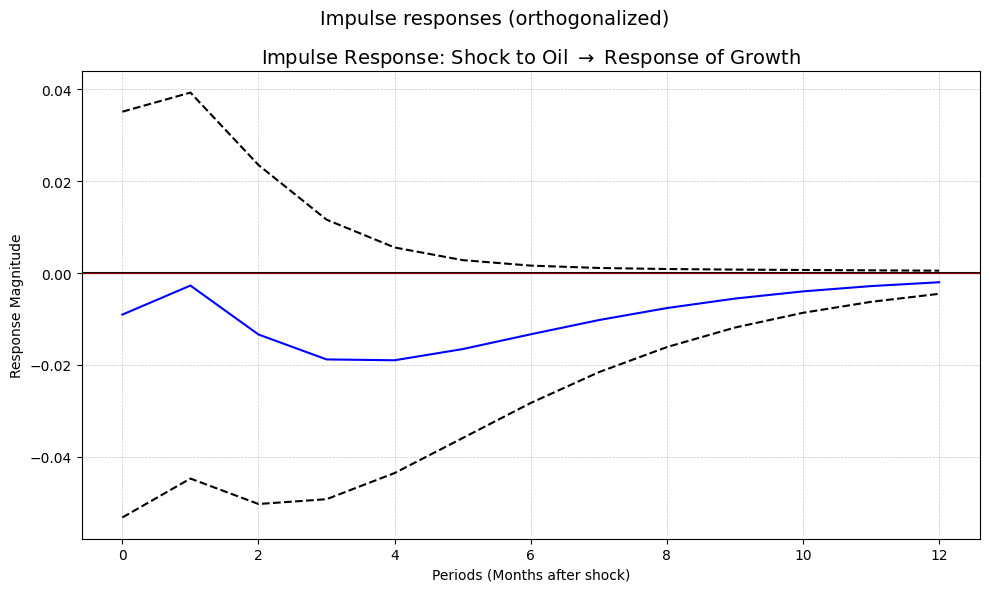

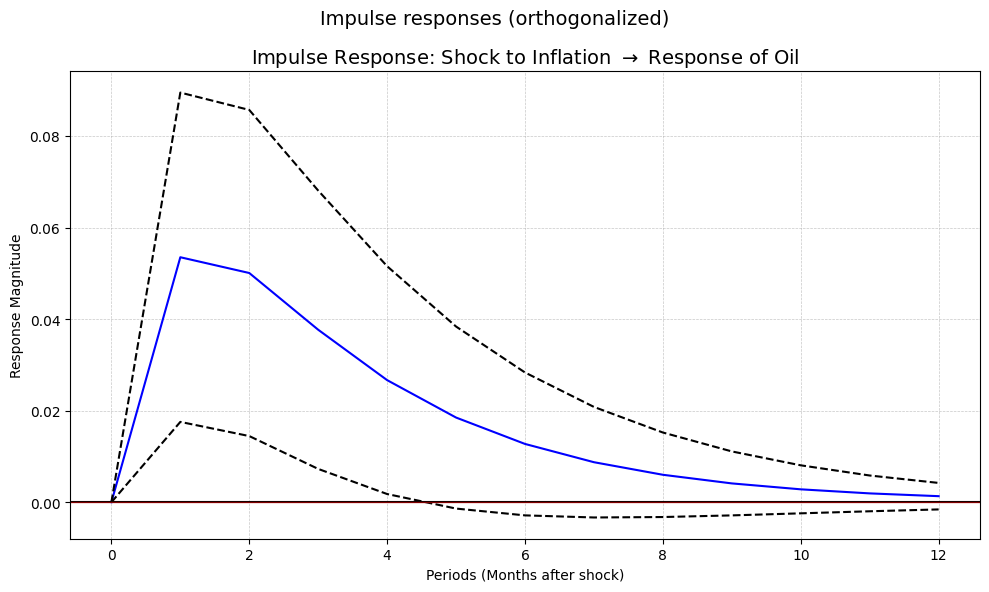

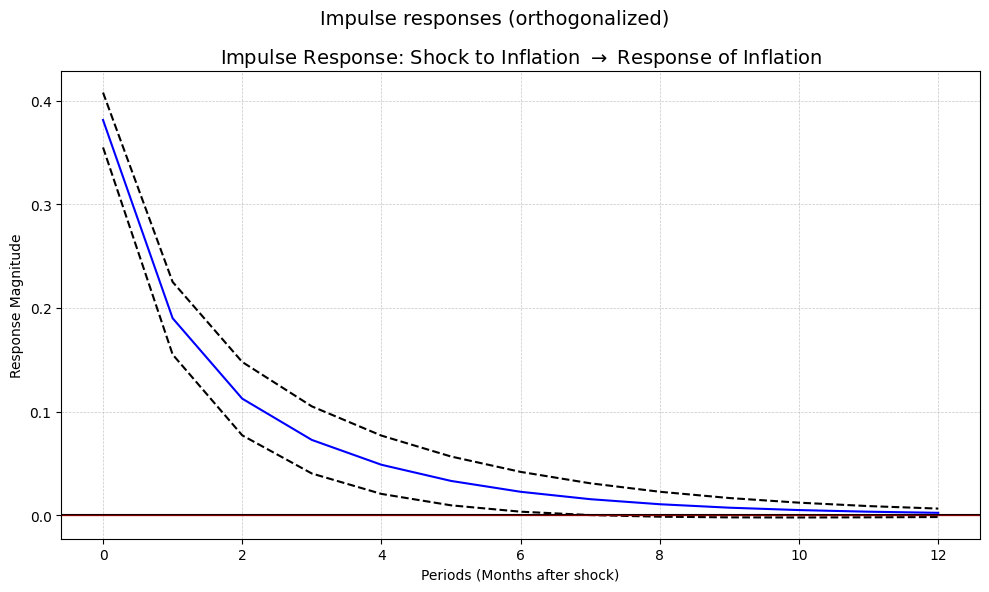

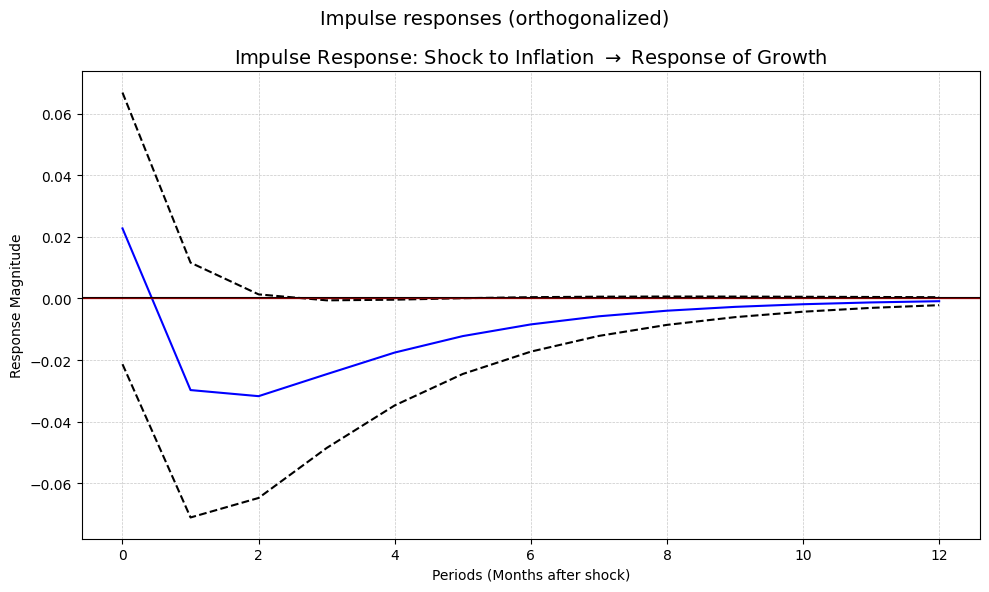

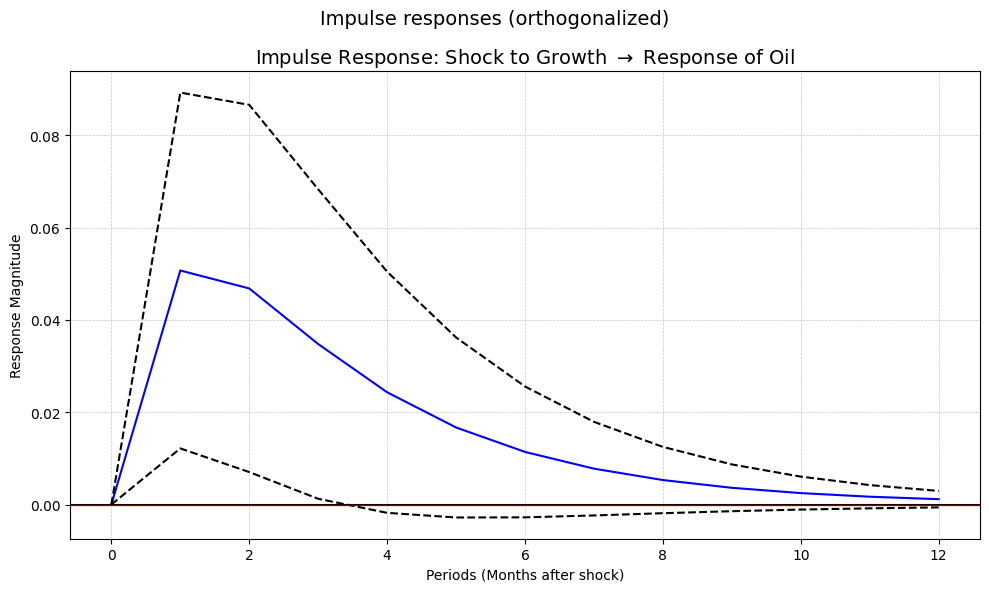

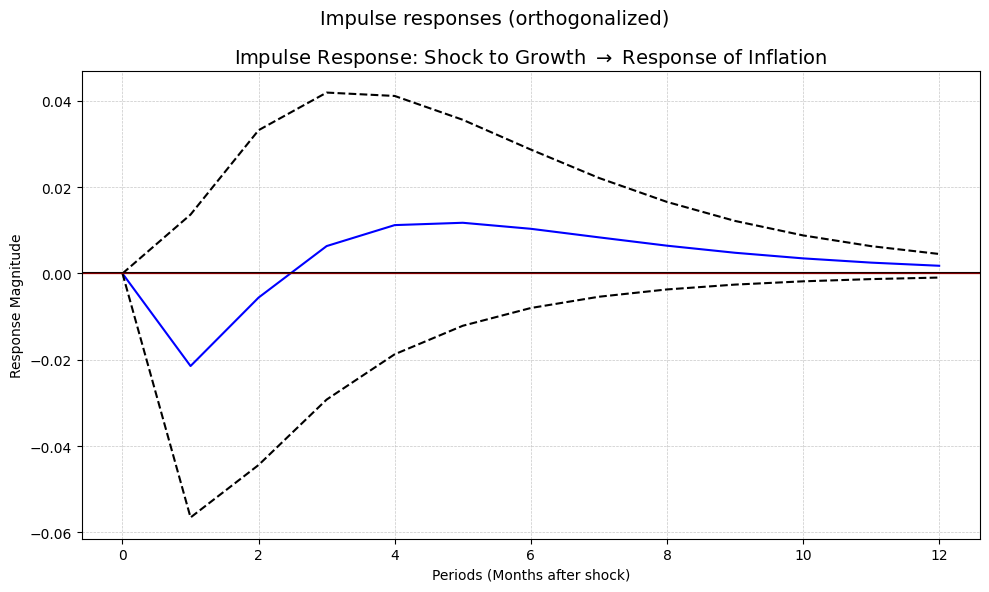

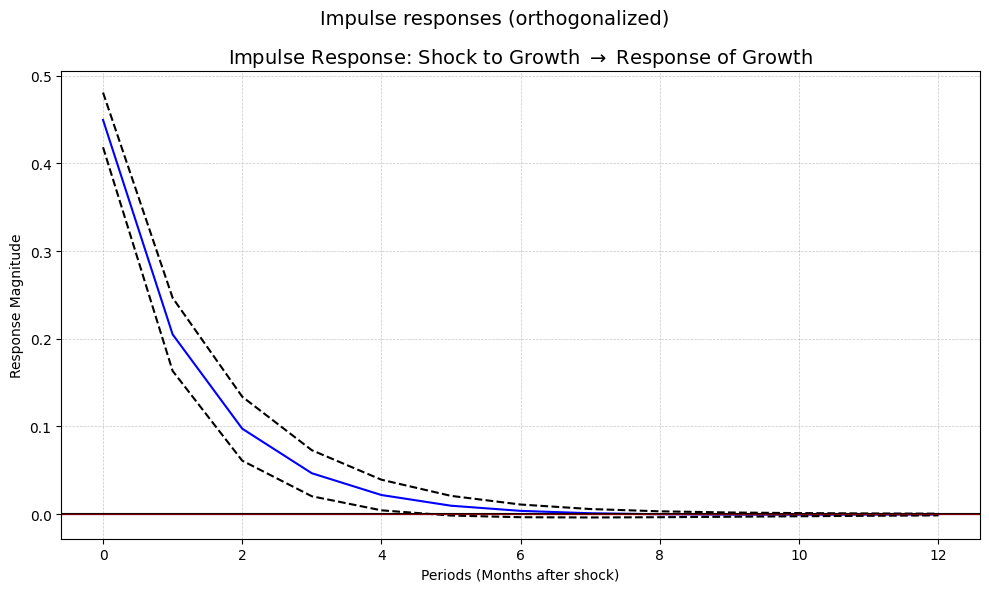

--- End of Plot Generation ---

--- Forecast Error Variance Decomposition ---
FEVD for Oil
          Oil  Inflation    Growth
0    1.000000   0.000000  0.000000
1    0.979218   0.010950  0.009832
2    0.965108   0.018492  0.016400
3    0.957971   0.022362  0.019667
4    0.954597   0.024216  0.021187
5    0.953026   0.025089  0.021885
6    0.952296   0.025499  0.022205
7    0.951956   0.025691  0.022353
8    0.951797   0.025782  0.022422
9    0.951722   0.025824  0.022453

FEVD for Inflation
          Oil  Inflation    Growth
0    0.105023   0.894977  0.000000
1    0.233630   0.764433  0.001937
2    0.303558   0.694684  0.001757
3    0.338605   0.659637  0.001758
4    0.355960   0.641949  0.002090
5    0.364524   0.632995  0.002481
6    0.368731   0.628481  0.002788
7    0.370786   0.626224  0.002990
8    0.371784   0.625106  0.003110
9    0.372266   0.624557  0.003177

FEVD for Growth
          Oil  Inflation    Growth
0    0.000403   0.002560  0.997037
1    0.000362   0.005720  0.9939

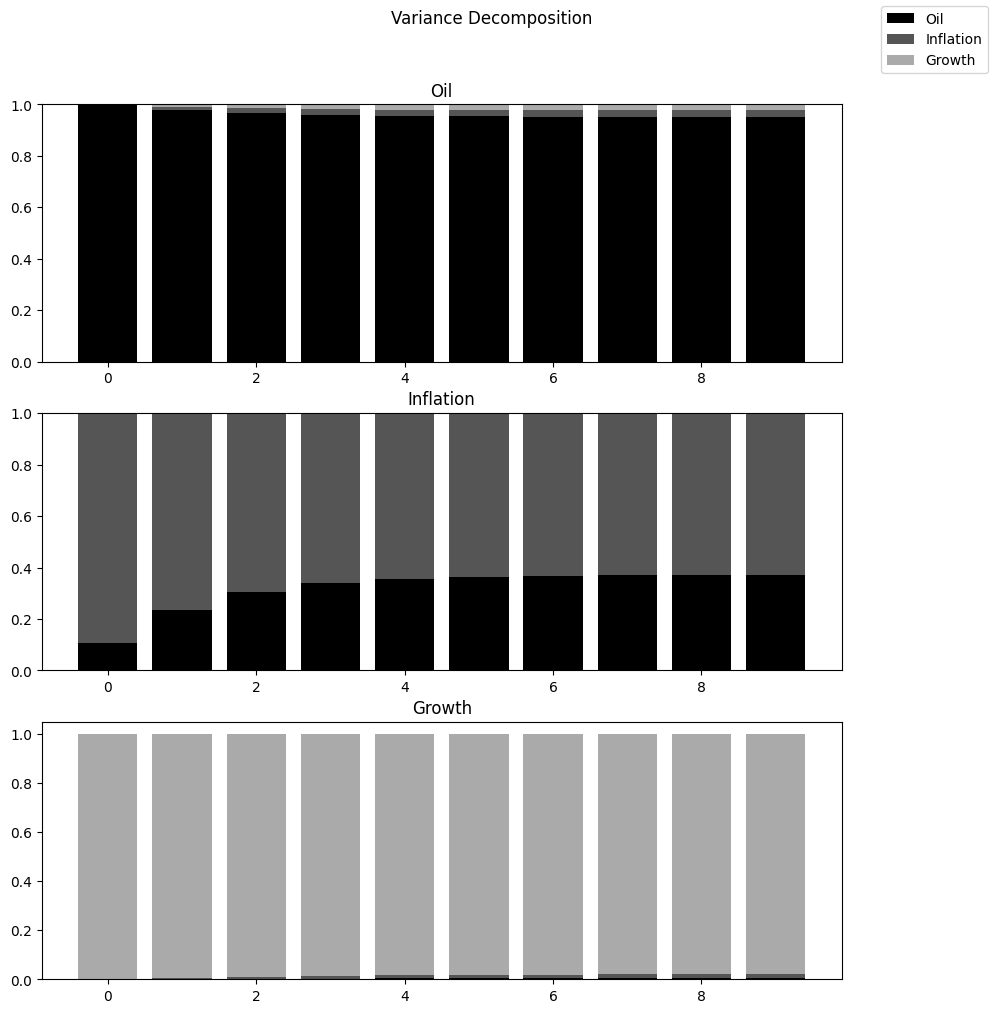


--- Matrice Correlazione Residui ---
                Oil  Inflation    Growth
Oil        1.000000   0.324073 -0.020068
Inflation  0.324073   1.000000  0.041366
Growth    -0.020068   0.041366  1.000000


In [8]:

# =============================================================================
# 1. CARICAMENTO E PREPARAZIONE DATI (3 VARIABILI)
# =============================================================================
file_path = 'Zeri_Tommaso.xlsx'
sheet_name = 'Ex.3'

print(f"--- Caricamento dati da: {file_path} (Foglio: {sheet_name}) ---")

# Lettura del file Excel
df = pd.read_excel(file_path, sheet_name=sheet_name)

# --- A. GESTIONE DATE (Colonna A "obs") ---
# Salviamo la prima colonna (indice 0) per le date
raw_dates = df.iloc[:, 0]

# --- B. SELEZIONE VARIABILI (Oil, Inflation, Growth) ---
# Il prompt specifica:
# Colonna A (0) = Date
# Colonna B (1) = Oil Price
# Colonna C (2) = Inflation Rate
# Colonna D (3) = Growth (GDP)
data = df.iloc[:, [1, 2, 3]]
data.columns = ['Oil', 'Inflation', 'Growth']

# --- C. CREAZIONE INDICE TEMPORALE ---
try:
    # Parsing del formato "1973m1" (Anno-m-Mese)
    data.index = pd.to_datetime(raw_dates, format='%Ym%m')
except Exception:
    print("Warning: Formato data non standard, tentativo con parser automatico...")
    data.index = pd.to_datetime(raw_dates, errors='coerce')

# Rimozione eventuali dati mancanti
data.dropna(inplace=True)

print(f"Dati caricati: {len(data)} osservazioni.")
print(data.head())
print("-" * 50)

# =============================================================================
# 2. PLOT DELLE SERIE STORICHE
# =============================================================================
# Normalizziamo visivamente per il plot (o usiamo assi doppi) per vedere tutto insieme
data.plot(subplots=True, figsize=(12, 10), title="Time Series: Oil, Inflation, Growth")
plt.tight_layout()
plt.show()

# =============================================================================
# 3. TEST DI STAZIONARIETÀ (ADF Test)
# =============================================================================
def adf_test(series, title=''):
    print(f'ADF Test: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]
    print(f'   Test Statistic: {result[0]:.4f}')
    print(f'   p-value:        {p_value:.4f}')
    if p_value <= 0.05:
        print("   => STAZIONARIA (H0 rifiutata)")
    else:
        print("   => NON STAZIONARIA (H0 accettata) -> Considera differenziare!")
    print("")

print("--- Verifica Stazionarietà ---")
for col in data.columns:
    adf_test(data[col], col)

# NOTA: Se 'Oil' risulta NON stazionaria (comune per i prezzi),
# potresti voler usare i log-returns invece del prezzo grezzo.
# Per farlo, decommenta le righe sotto:
# data['Oil'] = np.log(data['Oil']).diff()
# data.dropna(inplace=True)


# =============================================================================
# 4. SELEZIONE LAG OTTIMALE
# =============================================================================
model = VAR(data)
lag_selection = model.select_order(maxlags=10)
print(lag_selection.summary())

# Selezioniamo il lag suggerito da AIC
optimal_lag = lag_selection.aic
print(f"\nLag ottimale selezionato (AIC): {optimal_lag}")


# =============================================================================
# 5. FITTING DEL MODELLO VAR
# =============================================================================
print(f"--- Fitting VAR({optimal_lag}) ---")
results = model.fit(optimal_lag)
print(results.summary())


# =============================================================================
# 6. GRANGER CAUSALITY TESTS (TUTTE LE COPPIE)
# =============================================================================
print("\n=== GRANGER CAUSALITY MATRIX ===")
variables = data.columns

for target in variables:
    for predictor in variables:
        if target != predictor:
            print(f"\n[TEST] {predictor} Granger-Causes {target}?")
            # maxlag deve essere una lista o int. Usiamo il lag del modello.
            gc_res = grangercausalitytests(data[[target, predictor]], maxlag=[optimal_lag], verbose=False)

            # Estraiamo il p-value del test F (indice 0 del dizionario dei risultati)
            # gc_res[lag][0] contiene i test stats. 'ssr_ftest' è robusto.
            p_value = gc_res[optimal_lag][0]['ssr_ftest'][1]

            print(f"   p-value: {p_value:.4f}")
            if p_value < 0.05:
                print(f"   RISULTATO: SÌ ({predictor} causa {target}) ***")
            else:
                print(f"   RISULTATO: NO")

# =============================================================================
# 7. IMPULSE RESPONSE FUNCTIONS (IRF) - SEPARATE AND LARGE PLOTS (ENGLISH)
# =============================================================================
print("\n--- Generating Separate IRF Plots ---")

# Calculate IRF for 12 periods (one year)
periods = 12
irf = results.irf(periods)

# List of variables
# We iterate over columns to handle English names automatically (Oil, Inflation, Growth)
variable_names = data.columns

# Loop to generate a separate graph for EACH pair
for impulse in variable_names:
    for response in variable_names:

        # Create a single large plot (10x6 inches)
        # orth=True applies Cholesky decomposition (Structural identification)
        fig = irf.plot(orth=True, impulse=impulse, response=response, figsize=(10, 6))

        # --- CUSTOMIZATION IN ENGLISH ---

        # Title: "Shock to X -> Response of Y"
        plt.title(f'Impulse Response: Shock to {impulse} $\\to$ Response of {response}', fontsize=14)

        # Red line at zero for significance check
        plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.5)

        # Labels and Grid
        plt.xlabel("Periods (Months after shock)")
        plt.ylabel("Response Magnitude")
        plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)

        plt.tight_layout()
        plt.show()

print("--- End of Plot Generation ---")

# =============================================================================
# 8. VARIANCE DECOMPOSITION (FEVD)
# =============================================================================
print("\n--- Forecast Error Variance Decomposition ---")
fevd = results.fevd(10)
print(fevd.summary())

fevd.plot()
plt.suptitle('Variance Decomposition', y=1.02)
plt.show()


# =============================================================================
# 9. CORRELAZIONE DEI RESIDUI
# =============================================================================
print("\n--- Matrice Correlazione Residui ---")
print(results.resid.corr())

Ordine Variabili per VAR Strutturale (Cholesky): ['Oil', 'Inflation', 'Growth']
Lag Ottimale (AIC): 1


<Figure size 1000x800 with 0 Axes>

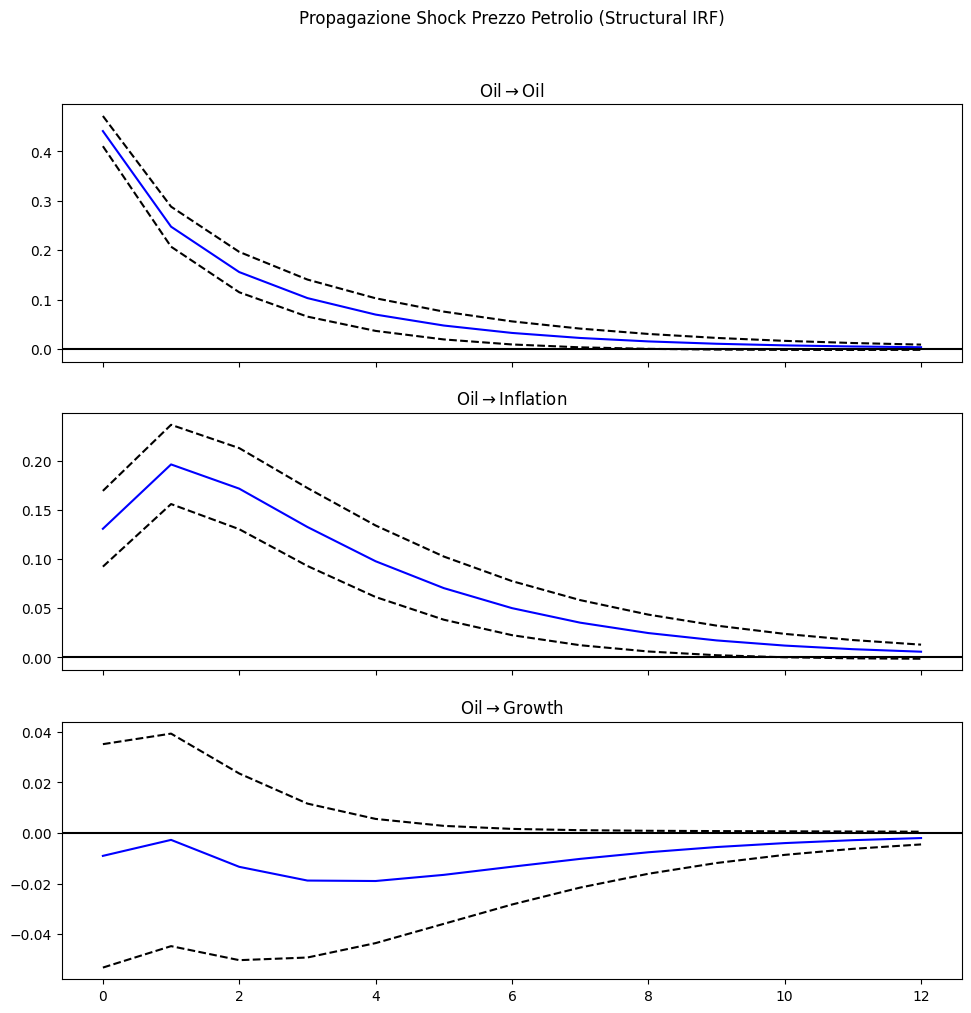


--- GUIDA ALLA DISCUSSIONE DEI RISULTATI ---
Guarda i grafici generati sopra (Oil -> Inflation, Oil -> Growth):
1. Oil -> Oil: Persistenza dello shock sul prezzo del petrolio.
2. Oil -> Inflation: Se la linea sale, lo shock petrolifero crea inflazione (Pass-through).
3. Oil -> Growth: Se la linea scende sotto zero, lo shock petrolifero deprime la crescita (Recessione).
L'intervallo tratteggiato indica l'intervallo di confidenza al 95%. Se lo zero è incluso, l'effetto non è statisticamente significativo.


In [9]:
# =============================================================================
# 1. CARICAMENTO DATI
# =============================================================================
file_path = 'Zeri_Tommaso.xlsx'
sheet_name = 'Ex.3'

df = pd.read_excel(file_path, sheet_name=sheet_name)
raw_dates = df.iloc[:, 0]

# SELEZIONE E ORDINAMENTO CRUCIALE PER 'SMALL OPEN ECONOMY'
# Ordine Variabili: [Oil, Inflation, Growth]
# Motivo Teoretico (Identificazione di Cholesky):
# 1. Oil Price: Variabile globale/esogena. Non reagisce contemporaneamente
#    alle variabili domestiche (Small Open Economy assumption).
# 2. Inflation/Growth: Variabili domestiche che reagiscono allo shock Oil.
data = df.iloc[:, [1, 2, 3]]
data.columns = ['Oil', 'Inflation', 'Growth']

# Gestione Date
try:
    data.index = pd.to_datetime(raw_dates, format='%Ym%m')
except:
    data.index = pd.to_datetime(raw_dates, errors='coerce')
data.dropna(inplace=True)

print("Ordine Variabili per VAR Strutturale (Cholesky):", data.columns.tolist())

# =============================================================================
# 2. STIMA DEL MODELLO
# =============================================================================
model = VAR(data)

# Selezione Lag ottimale
lag_selection = model.select_order(maxlags=10)
optimal_lag = lag_selection.aic
print(f"Lag Ottimale (AIC): {optimal_lag}")

# Fitting
results = model.fit(optimal_lag)

# =============================================================================
# 3. IMPULSE RESPONSE FUNCTIONS (ANALISI SHOCK PETROLIO)
# =============================================================================
# La richiesta chiede di discutere il "propagation mechanism of oil price shocks".
# Calcoliamo la IRF ortogonalizzata (Cholesky) a 10/12 periodi
irf = results.irf(12)

# PLOT SPECIFICO: SHOCK SU 'OIL'
# Visualizziamo solo la risposta delle variabili domestiche a uno shock su Oil
# impulse='Oil' -> La causa
# orth=True -> Applica Cholesky (Cruciale per definire 'Structural')
plt.figure(figsize=(10, 8))
irf.plot(orth=True, impulse='Oil')
plt.suptitle('Propagazione Shock Prezzo Petrolio (Structural IRF)', y=1.02)
plt.show()

# =============================================================================
# 4. COMMENTO PER L'ANALISI (OUTPUT TESTUALE)
# =============================================================================
print("\n--- GUIDA ALLA DISCUSSIONE DEI RISULTATI ---")
print("Guarda i grafici generati sopra (Oil -> Inflation, Oil -> Growth):")
print("1. Oil -> Oil: Persistenza dello shock sul prezzo del petrolio.")
print("2. Oil -> Inflation: Se la linea sale, lo shock petrolifero crea inflazione (Pass-through).")
print("3. Oil -> Growth: Se la linea scende sotto zero, lo shock petrolifero deprime la crescita (Recessione).")
print("L'intervallo tratteggiato indica l'intervallo di confidenza al 95%. Se lo zero è incluso, l'effetto non è statisticamente significativo.")